# Laboratorio de Datos II - Guía de Ejercicios N° 1
## Análisis Exploratorio de Datos y Visualización

Dataset: Palmer Penguins

### LIBRERIAS

In [1]:
%pip install seaborn matplotlib pandas numpy scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# Ejercicio 1: Estadística Descriptiva y Análisis Univariado
**Carga del dataset y estructura básica:**

In [3]:
datos_penguins = sns.load_dataset('penguins')

#exploracion inicial
print("Dimensiones:", datos_penguins.shape)
print("Información general (info):")
datos_penguins.info()
print("Valores faltantes por columna:")
print(datos_penguins.isnull().sum())

Dimensiones: (344, 7)
Información general (info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
Valores faltantes por columna:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


BASICAMENTE ACA CONCLUIMOS QUE TENEMOS 344 FILAS (pinguinos) Y QUE CADA UNO TIENE 7 CARACTERISTICAS. hay algunos datos que faltan, por ejemplo hay 2 filas que no tienen 'bill_length_mm' o su 'flipper_length_mm' y lo mas llamativo es que 11 pinguinos no tienen el dato de su sexo.

el 'RangeIndex' simplemente dice como pandas enumera las filas, de 0 a 343.

Traduccion de las caracteristicas:

species (object): La especie del pingüino (puede ser Adelie, Chinstrap o Gentoo).

island (object): La isla de la Antártida donde fue registrado (Torgersen, Biscoe o Dream).

bill_length_mm (float64): Longitud del pico en milímetros. (El "culmen" o pico, desde la base hasta la punta).

bill_depth_mm (float64): Profundidad del pico en milímetros. (Qué tan grueso o alto es el pico midiendo de arriba a abajo).

flipper_length_mm (float64): Longitud de la aleta en milímetros.

body_mass_g (float64): Masa corporal o peso del pingüino, medido en gramos.

sex (object): El sexo del pingüino (Macho o Hembra)

Ahora me surge una duda... a los pinguinos que le faltan las medidas de su pico, son los dos mismos que le faltan la medida de su aleta? y a su vez estos 2 pinguinos estan dentro de los 11 que no tienen su sexo? es decir me parece logico pensar que si no se le pudo medir a un pinguino su pico, tampoco su aleta o su aleta, tampoco el sexo. 
Eliminemos esta duda... verifiquemos si hay superposicion de datos faltantes o si son pinguinos diferentes. Para eso verifiquemos la cantidad de pinguinos con datos faltantes.

In [4]:
# Esto nos filtra y muestra solo las filas que tienen al menos 
# un dato faltante en cualquier columna
datos_penguins[datos_penguins.isnull().any(axis=1)]

#axis=1 mirar horizontalmente (por fila), si hay un nulo en esa fila
# toda la fila sera true, entonces gracias a los corchetes exteriores
#basicamente le decimos, de mi tabla 'datos_penguins'
#muestrame las filas donde hay algun (any()) valor nulo.

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


EFECTIVAMENTE VERIFICAMOS QUE LA SUPOSICION FUE LOGICA, LOS PINGUINOS A LOS CUALES NO SE LE PUDIERON MEDIR EL PICO Y LA ALETA, SON LOS MISMOS A LOS QUE NO SE LE PUDIERON MEDIR LA MASA Y EL SEXO.

In [5]:
#descriptivas fundamentales (media, desviacion estandar, cuartiles)
datos_penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [6]:
#Mediana para variable numericas
datos_penguins.median(numeric_only=True)

bill_length_mm         44.45
bill_depth_mm          17.30
flipper_length_mm     197.00
body_mass_g          4050.00
dtype: float64

In [7]:
#moda (para numericas)
datos_penguins.mode(numeric_only=True)
#es el valor que mas se repite para cada caracteristica.

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,41.1,17.0,190.0,3800.0


### Estadisticas de orden superior (asimetria y curtosis)
solo funcionan y tienen sentido para variables numericas,se construyen a partir de la media y la varianza

El concepto de "Cola" y "Dirección": La asimetría nos dice si los datos se estiran hacia valores muy altos (derecha) o muy bajos (izquierda).

El concepto de "Outlier" (Valor atípico extremo): La curtosis mide qué tan probables son los valores numéricamente extremos.

In [8]:
from scipy.stats import skew , kurtosis

#primero filtramos solo las columnas numericas y eliminamos
#las filas con nulos

datos_numericos =datos_penguins.select_dtypes(include=[np.number]).dropna()

#vemos la asimetria y kurtosis para cada columna numerica
for columna in datos_numericos.columns:
    valor_asimetria=skew(datos_numericos[columna])
    valor_curtosis=kurtosis(datos_numericos[columna])

    print(f"Caracteristica: {columna}")
    print(f"Asimetria:{valor_asimetria:.3f}")
    print(f"Curotsis: {valor_curtosis:.3f}")
    


Caracteristica: bill_length_mm
Asimetria:0.053
Curotsis: -0.881
Caracteristica: bill_depth_mm
Asimetria:-0.143
Curotsis: -0.911
Caracteristica: flipper_length_mm
Asimetria:0.344
Curotsis: -0.987
Caracteristica: body_mass_g
Asimetria:0.468
Curotsis: -0.726



### Analisis de asimetria

bill_length_mm (0.053) y bill_depth_mm (-0.143):

Ambos valores estan cerca de 0 (el primero ligeramente positivo, el segundo ligeramente negativo).
Las medidas del pico de los pinguinos en este dataset tienen una distribución casi perfectamente simetrica. No hay una tendencia fuerte hacia picos largos ni cortos, la cantidad de pinguinos con picos por debajo del promedio compensa casi exactamente a los que están por encima

flipper_length_mm (0.344) y body_mass_g (0.468):

Ambos tienen una asimetria positiva. Nos indican que la cola de la distribucion se estira hacia la derecha. Esto significa que la gran masa de pinguinos tiende a ser mas liviana y de aletas mas cortas, pero existen pinguinos significativamente mas grandes y pesados que tiran el promedio para arriba.

### Anaalisis de kurtosis

Todos los valores son negativos, quiere decir que todas las variables presentan una distribucion platicurtica(curtosis negativa y alejada del 0). Esto significa que hay falta de outliers (por ej: no hay pinguinos extremadamente chiquitos ni muy grandes) y que ademas la distribucion es chata, los datos estan repartidos de forma pareja a lo largo del rango (tiene forma de meseta.)




### Histogramas
muesta la distriibucion de la frecuencia a lo largo de intervalos (bins), permite apreciar de forma general si hay uno o varios picos (modas), si la distribucion es simetrica o sesgada, si presenta colas laregas,etc.

histogramas usando seaborn


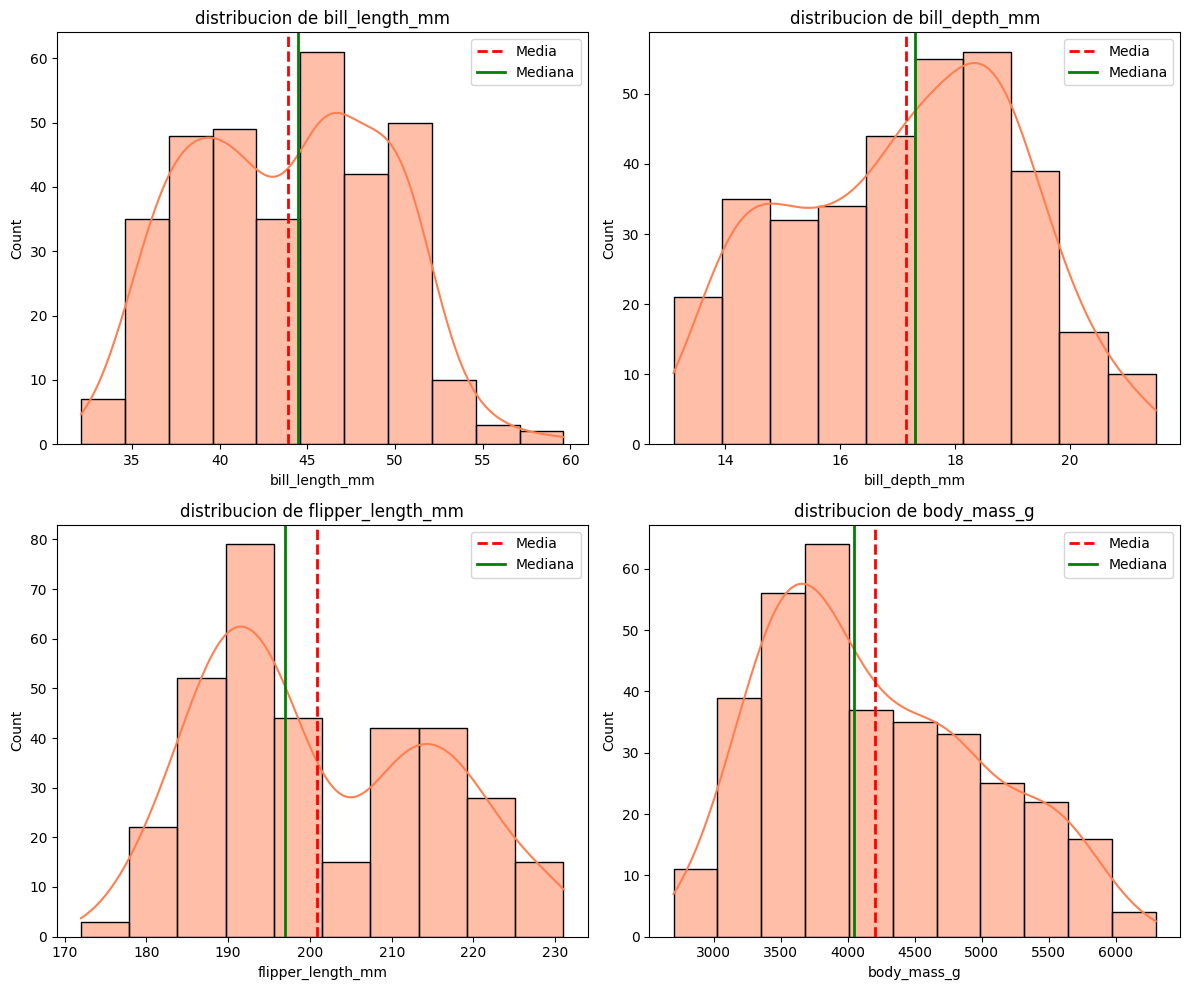

In [10]:
#histograma con seaborn 
print("histogramas usando seaborn")
#preparamos una grilla de 2 filas x 2 columnas
fig,axes=plt.subplots(2,2,figsize=(12,10))
#axes.flatten convierte la grilla de 2x2 en una lista simple de 4 espacios
espacios=axes.flatten()

#reccrremos cada columna numerica y le asignamos un espacio
for i,columna in enumerate(datos_numericos.columns):
    sns.histplot(data=datos_penguins,x=columna,ax=espacios[i],kde=True,color='coral')
    #histplot crea el grafico, x: que columna va a graficar,ax: en que pedacito lo dibujamos
    #kde=True agrega una linea curva suave por encima de las barras
    
    media= datos_numericos[columna].mean()
    mediana=datos_numericos[columna].median()

    #agreggamos la emdia y mediana como lineas en los graficos
    espacios[i].axvline(media, color='red', linestyle='--', linewidth=2, label='Media')
    espacios[i].axvline(mediana, color='green', linestyle='-', linewidth=2, label='Mediana')
    
    espacios[i].set_title(f'distribucion de {columna}')
    espacios[i].legend()
    
plt.tight_layout()
plt.show()

### Analisis de los histogramas
Lo primero y mas importante es que el kde revela que las distribuciones no forman una campana de gauss perfecta (no son unimodales). Especialmente en 'bill_lenght_mm' y 'flipper_lenght_mm' se ven "dos montañas", a esto lo conocemos como distribucion bimodal... esto verifica que estamos viendo a especies distintas de pinguinos, estos "picos" representan los diferentes tamaños promedio de cada especie (algunas son mas grande que otras)

Con respecto a la longitud y profundidad del pico vemos que las medias y medianas estan casi superpuestas, mostrando graficamente lo que calculamos anteriormente (asimetria casi 0).Ademas, como vimos en el analisis anterior, la curtosis daba valores negativos (platicurtida), lo que nos dice que los datos no se concentran en el centro, sino que se escapan hacia los costados.

En relacion a la longitud de la aleta notamos una asimetria positiva , la media esta desviada hacia la derecha de la mediana. Esto se debe a que hay un grupo de pinguinos con aletas normales/chiquitas y otro grupo (mas pequeño) con aletas mucho mas grande. Este segundo grupo actua como una "cola pesada", tirando el promedio hacia arriba.

Mirando el histograma de la masa corporal, notamos que al igual que con las aletas, la asimetría es positiva. La linea roja (Media) se despega hacia la derecha de la verde (Mediana).Esto indica que la gran mayoria de los pinguinos pesan alrededor de 3500-4000g (donde esta el pico mas alto), pero existe una subpoblación que pesa mas, estirando el grafico hacia la derecha.

### Boxplots
la caja central abarca de Q1 a Q3 (IQR), la linea interna es la mediana. Los bigotes suelen extenderse 1,5 veces el IQR desde cada cuartil, indicando el rango tipico de dispersion, cualquier punto fuera de ese rango puede considerarse un "outlier".

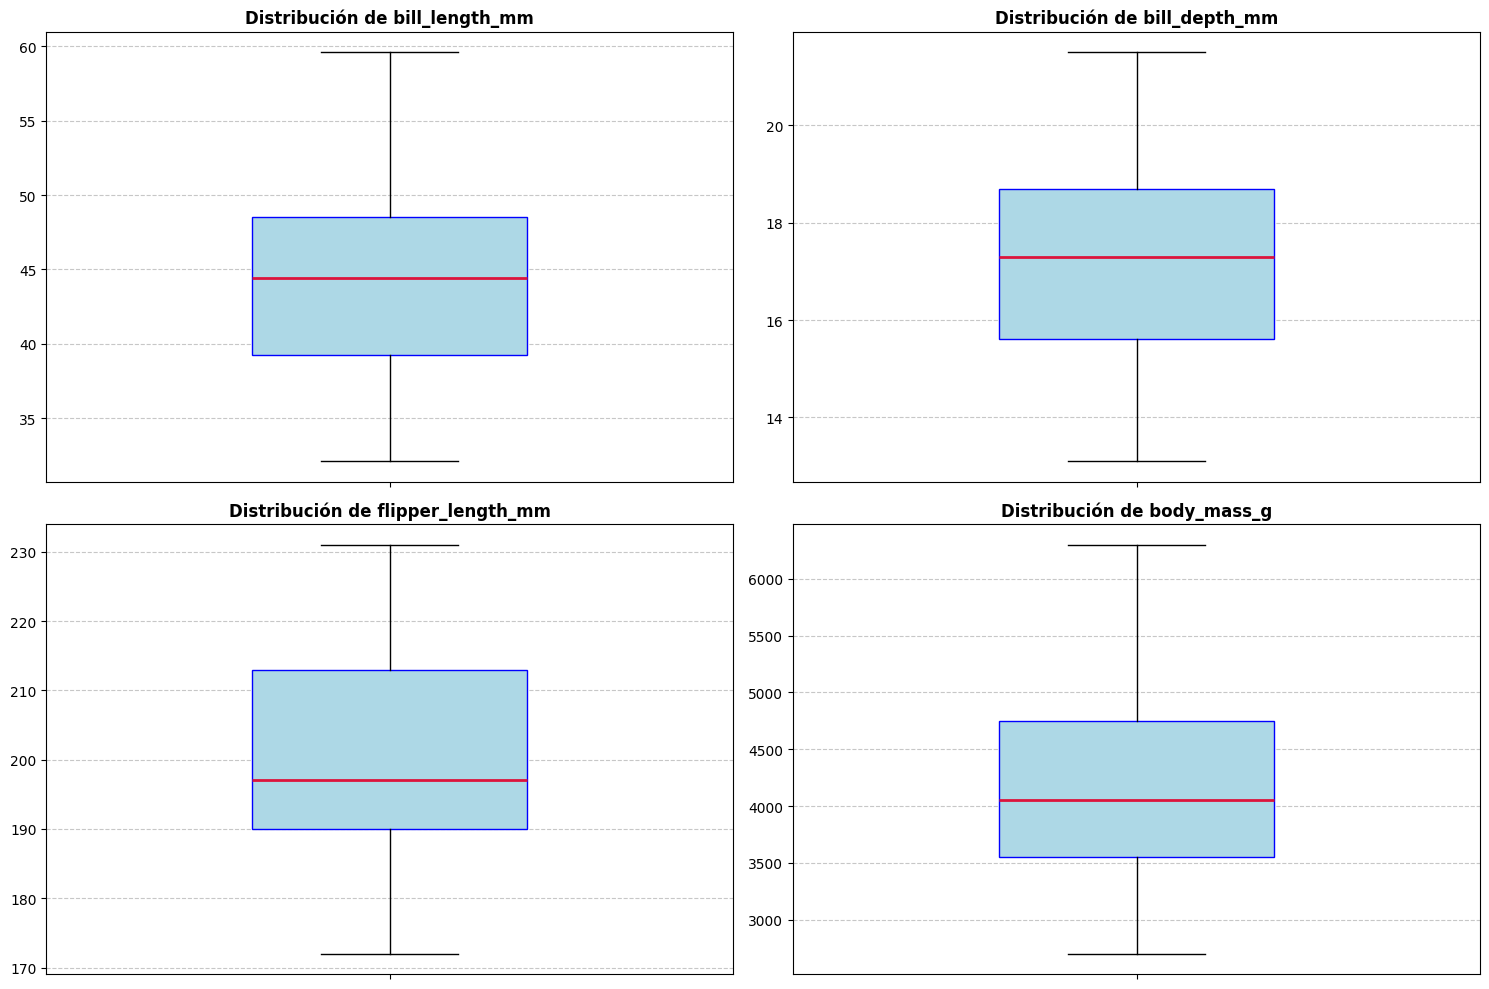

In [11]:
#con matplotlib pq me quedo mas facherito
plt.figure(figsize=(15,10))
for i, columna in enumerate(datos_numericos.columns, 1):
    plt.subplot(2, 2, i)
    
    # 'patch_artist=True' nos permite rellenar la caja con color
    # 'boxprops' controla el color de la caja y los bordes
    # 'medianprops' le da un color rojo y más grosor a la línea central
    plt.boxplot(datos_numericos[columna], widths=0.4,patch_artist=True, boxprops=dict(facecolor='lightblue', color='blue'),
            medianprops=dict(color='crimson', linewidth=2))
    
    plt.title(f"Distribución de {columna}", fontsize=12, fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.7) # Agregamos líneas guía horizontales
    plt.xticks([1], ['']) # Quitamos el número '1' suelto que pone Matplotlib abajo
plt.tight_layout()
plt.show()

#### analisis boxplots
Aca podemos notar que todos los daots caen en el rango normal (dentro del 1,5xIQR) para cada variable numerica, por lo que no se identifican outliers. Pero un detalle muy importante es que estamos metiendo dentro del mismo boxplot las 3 ESPECIES DE PINGUINOS. Al juntar las especies grandes con las chicas , la caja se estira mucho y el rango considerado "normal" se vuelve mas grande.
podemos preguntarnos que pasaria si separamos las especies y hacemos un boxplot por especie,habria outliers?


### Hagamos un analisis por especie. Identifiquemos cuantos hay de cada una , en que islas estan, cuantos machos y hembras hay (recordando que faltan 11 datos de sexo)

In [12]:
variables_categoricas = ['species','island','sex']
for columna in variables_categoricas:
    print(f'frecuencia de {columna}')

    #value_counts() cuenta cuantas veces aparece cada categoria
    print (datos_penguins[columna].value_counts())
    print("\n")

frecuencia de species
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


frecuencia de island
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64


frecuencia de sex
sex
Male      168
Female    165
Name: count, dtype: int64




### ANALISIS DE CATEGORICAS
Podemos detectar claramente un desbalanceo en las especies, hay mas del doble pinguinos adelie que pinguinos chinstrap. Si dsp queremos entrenar un modelo para clasificar,aprendera muy bien a reconocer los adelie pero le va a costar mas reconocer un chisntrap. Gracias a esto ya sabemos que a futuro vamos a necesitar alguna TECNICA DE MUESTREO ESTRATIFICADO
Con respecto al sexo el dataset esta balanceado, por lo que si luego descubrimos que una especie es mas pesada que otra, podemos asegurar que no es un error causado por que medimos puros machos.
La isla Torgensen tiene muy pocos registros , mas adelante va a ser complicado sacar conclusiones sobre como es la vida en esta isla debido a que la muestra es chica y el margen de error puede ser grande.





## REPORTE DESCRIPTIVO UNIVARIADO, CONCLUSION EJERCICIO 1

1. El conjunto original cuenta con 344 observaciones. Detectamos una superposicion en los valores faltantes: existen 2 individuos a los que no se les pudo registrar ninguna medida ni el sexo, y otros 9 individuos que carecen unicamente de la variable sex.

2. Analisis de variables numericas:
Medidas de pico (bill_length_mm y bill_depth_mm): Poseen una asimetria casi nula (0.053 y -0.143 respectivamente). Esto indica una distribucion central simetrica, sin tendencia hacia losextremos.
Masa corporal y aletas (body_mass_g y flipper_length_mm): Presentan asimetria positiva (0.468 y 0.344). Esto significa que la mayor cantidad de pinguinos se agrupan en pesos y tamaños de aleta menores o promedio, existiendo una "cola" hacia la derecha generada por algunos pingüinos significativamente más grandes y pesados.
Curtosis: Las cuatro variables numericas presentan curtosis negativa (distribuciones platicurticas), lo que indica una distribucion más plana ("achatada") y con colas livianas, anticipando una baja probabilidad de encontrar valores extremos.

3. Analisis de outliers: los diagramas de caja (boxplots) a nivel global no detectan valores atipicos univariados. Ninguna de las medidas sobrepasa los limites de 1.5 veces el rango intercuartilico (IQR). Sin embargo, al estar las tres especies agrupadas, la escala es muy amplia.

4. variables categoricas:
Especies: Existe un claro desbalance en el dataset. La especie Adelie domina la muestra (152 casos), seguida por Gentoo (124), siendo Chinstrap la minoria (68).
Islas: Biscoe es la isla con mas registros (168), mientras que de Torgersen se obtuvieron menos de la tercera parte (52).
Sexo: Es la unica categoria con un balance casi perfecto (168 machos vs 165 hembras), garantizando que las futuras comparaciones por género no sufriran sesgos de muestreo

El desbalance en las categorias (especie e isla) obliga a ser cuidadosos en los analisis cruzados, ya que los grupos minoritarios tendran mayor error estadistico. Ademas, la ausencia de outliers globales hace necesario avanzar hacia el analisis bivariado para verificar si existen outliers locales (por ejemplo, un pinguino pesado para ser Adelie, pero normal en el contexto de todo el dataset).

# EJERCICIO 2: Analisis bivariado - correlaciones y asociaciones

## Comenzamos con un analisis entre las categoricas. Me interesa saber por ejemplo si una especie solo vive en una isla o si se mezclan entre si y si hay algun tipo de sesgo por genero

In [13]:
#especie vs isla
print('ESPECIE VS ISLA')
contingencia_isla_especie=pd.crosstab(datos_penguins['island'],datos_penguins['species'],margins=True,
        margins_name="total")
display(contingencia_isla_especie)

ESPECIE VS ISLA


species,Adelie,Chinstrap,Gentoo,total
island,,,,
Biscoe,44,0,124,168
Dream,56,68,0,124
Torgersen,52,0,0,52
total,152,68,124,344


Podemos notar que a pesar de que la especie Adelie no tiene una isla preferida, se distribuye casi de manera identica en las 3 islas, por lo que se puede concluir que es la que mejor se adapta al territorio.

En cuanto a las proporciones de cada isla , vemos que la Dream es la mas equilibrada. Por su parte, en Biscoe se ve que la especie dominante es la Gentoo (con el total de su poblacion) , mientras que la especie Adelie es la minoria.

Ya se puede notar que hay dependencia entre isla y especie, y esto significa que una varibale da informacion sobre la otra. Por ejemplo, si sabemos que un pinguino es Gentoo, tenemos 100% de certeza de que vive en Biscoe o que si nos encontramos en Torgensen, tenemos 100% de certeza de que el pinguino es Adelie.



### determinemos formalmente si  las asociaciones son estadisticamente significativas, en la teoria se menciona que se usa el test de chi-cuadrado y lo vamos a visualizar con un heatmap de frecuencias observadas (basicamente es la tabla de contingencia pintada) y ademas un heatmap de los residuos de pearson (como se muestra en la teoria)

Podemos pensar a la hipotesus nula como: H0= 'La especie y la isla no tienen nada que ver'(son independientes). si esto fuera cierto los pinguinos se distribuirian por las islas de forma proporcional. A este calculo se lo conoce como frecuencia esperada.
Vemos que los pinguinos no se distribuyen al azar, aca entra el residuo de pearson, que mide la diferencia entre la realidad (frecuencias observadas) y el azar (frecuencias esperadas).
- Colores rojos = Asociacion positiva, hay mas pnguinos en esa combiancion de lo que se esperaba
- Colores azules = asociacion negativa, hay menos pinguinos de lo esperado
- Color blanco = independenci, la cantidad de pinguinos coincide con lo esperado

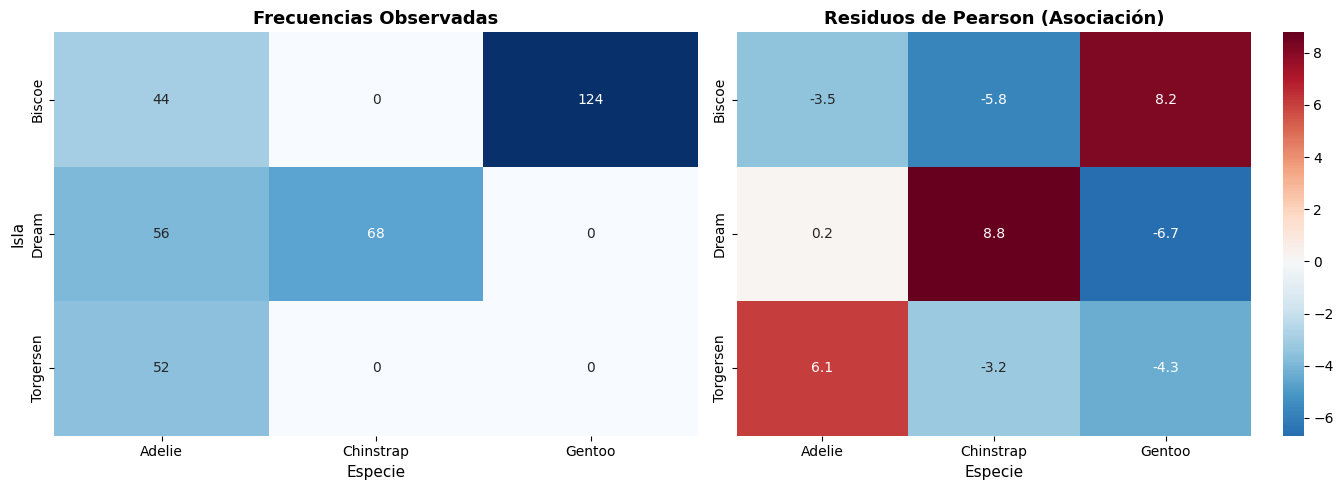

In [14]:
from scipy.stats import chi2_contingency

#volvemos a crear la tabla pero sin los totales (margins) para que el
#grafico quede limpio
tabla_isla_especie=pd.crosstab(datos_penguins['island'],datos_penguins['species'])

#calculamos los valores esperados usando chi-cuadrado (tal cual esta en la teoria)
chi2,p,gl,esperado=chi2_contingency(tabla_isla_especie)

#calculamos los "residuos de pearson" que tiene la siguiente formula
#(observado - esperado)/raiz cuadrada de esperado
residuos=(tabla_isla_especie - esperado)/np.sqrt(esperado)

#visualizamos
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

#heatmpa 1, frecuencias observadas (obvio se lo pedi a la IA tmp la pavada)
sns.heatmap(tabla_isla_especie, annot=True, fmt="d", cmap="Blues", ax=ax[0], cbar=False)
ax[0].set_title("Frecuencias Observadas", fontsize=13, fontweight='bold')
ax[0].set_ylabel("Isla", fontsize=11)
ax[0].set_xlabel("Especie", fontsize=11)

#heatmap 2, residuos de pearson (es el equivalente a la correlacion)
sns.heatmap(residuos, annot=True, fmt=".1f", cmap="RdBu_r", center=0, ax=ax[1])
ax[1].set_title("Residuos de Pearson (Asociación)", fontsize=13, fontweight='bold')
ax[1].set_ylabel("") # Quitamos el título de y para no repetir
ax[1].set_xlabel("Especie", fontsize=11)
plt.tight_layout()
plt.show()



### Analisis de los resultados:

La diagonal roja que se observa nos dice que cada especie tiene un territorio fuertemente asociado a ella.
- Ademas de las asociaciones fuertes de chinstrap y la isla dream o Gentoo con la isla Biscoe , como Adelie es la unica especie que habita en Torgensen, tambien hay una asociacion alta.

Los cuadrados azul oscuro indican que las especies evitan o no pueden sobrevivir en esas islas. 
- Una observacion interesante que noto es el de Adelie en Biscoe, se supone que Biscoe es la isla mas grande (o eso se entiende pq es la isla donde se concentra aprox la mitad de las muestras) y aunque hay 44 pinguinos , el color azul (-3,5) indica que son menos de lo esperado, esto entiendo que pasa porque como Adelie es la especie mas comun y Biscoe la isla mas grande, deberian haber muchos mas. Puede ser que como hay muchos Gentoo en esa isla, dominan y reprimen a los Adelie (los tienen de exclavos).

Luego otro resultado interesante es el de Adelie en la isla Dream, significa que los 56 pinguinos son la cantidad casi exacta que la probabilidad esperaba. Quiere decir que Adelie convive tranqui con Chinstrap, son amiguitos.

Podemos concluir entonces que la distribucion de especies no es aleatoria y que esta determinada por la geografia de las islas.


### Ahora me interesa saber si la proporcion del sexo en cada especie es pareja y si la distribucion es similar en cada isla (seria mas un analisis para el Adelie que para las otras especies)



In [15]:
#limpiamos los datos eliminando las filas donde falta el sexo
penguins_sexo=datos_penguins.dropna(subset=['sex'])

#analizamos el sexo por especie
tabla_sexo_especie=pd.crosstab(penguins_sexo['sex'],penguins_sexo['species'])
display(tabla_sexo_especie)

#hacemos un chi-cuadrao, nivel de signifcancia 0,05
#H0:el sexo es independiente de la especie
#H1: el sexo es dependiente de la especie
chi2_esp,p_especie,gl_esp,esperado_esp= chi2_contingency(tabla_sexo_especie)
print(f"p-valor= {p_especie:.3f}")

species,Adelie,Chinstrap,Gentoo
sex,,,
Female,73,34,58
Male,73,34,61


p-valor= 0.976


In [16]:
#analisis del sexo por isla
tabla_sexo_isla=pd.crosstab(penguins_sexo['sex'],penguins_sexo['island'])
display(tabla_sexo_isla)

#test chi-cuadrado, nivel de signifcancia 0,05
#H0: el sexo del pinguino es independiente de su isla
#H1: existe una dependecncia entre el sexo y la isla
chi2_isla,p_isla,gl_isla,esperado_isla=chi2_contingency(tabla_sexo_isla)
print(f"p-valor= {p_isla:.3f}")

island,Biscoe,Dream,Torgersen
sex,,,
Female,80,61,24
Male,83,62,23


p-valor= 0.972


### Analisis de sesgo de genero (sexo vs especie e isla)

observando el cruce entre estas variables notamos a simple vista que el dataset presenta una distribucion simetrica en cuanto al sexo de los pinguinos.
- por especie: adelie y chinstrap tienen una distribucion exacta
- por isla: el margen de diferencia es minimo.

Al realizar la verificacion estadistica aplicams la prueba de independecia de chi-cuadrado.
- sexo vs especie: obtuvimos un p`-value=0,976
- sexo vs isla: '''' p-value= 0.972

Conclusion: como el p-value es muy superior al nivel de significancia (0,05) y muy cercano a 1, podemos concluir que el sexo del pinguino es independiente tanto de su especie como de la isla que habita, fallamos al rechazar la hipotesis nula.

## Ahora si, arranco con el bivariado de las numericas y sigamos las consignas (lo anterior capaz se puede eliminar)

## 2.1

El método corr() de Pandas calcula el Coeficiente de Pearson, que devuelve un número entre -1 y 1:
- Cercano a +1: Correlación Positiva Fuerte. (Si uno sube, el otro sube).
- Cercano a -1: Correlación Negativa Fuerte. (Si uno sube, el otro baja).
- Cercano a 0: No hay correlación lineal (Parece no haber relación). 

La Matriz de Correlación es simplemente una tabla que cruza todas las variables contra todas las variables y te muestra esos números.

El Heatmap (Mapa de Calor) El cerebro humano no es bueno leyendo una tabla llena de números decimales cruzados. El Heatmap traduce esa matriz matemática a colores.
- Rojo oscuro = Fuerte relación positiva (Cercano a 1).
- Azul oscuro = Fuerte relación negativa (Cercano a -1).
- Blanco / Color pálido = No hay relación (Cercano a 0).


matriz de correlacion numerica


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.235053,0.656181,0.595110
bill_depth_mm,-0.235053,1.000000,-0.583851,-0.471916
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202
body_mass_g,0.595110,-0.471916,0.871202,1.000000


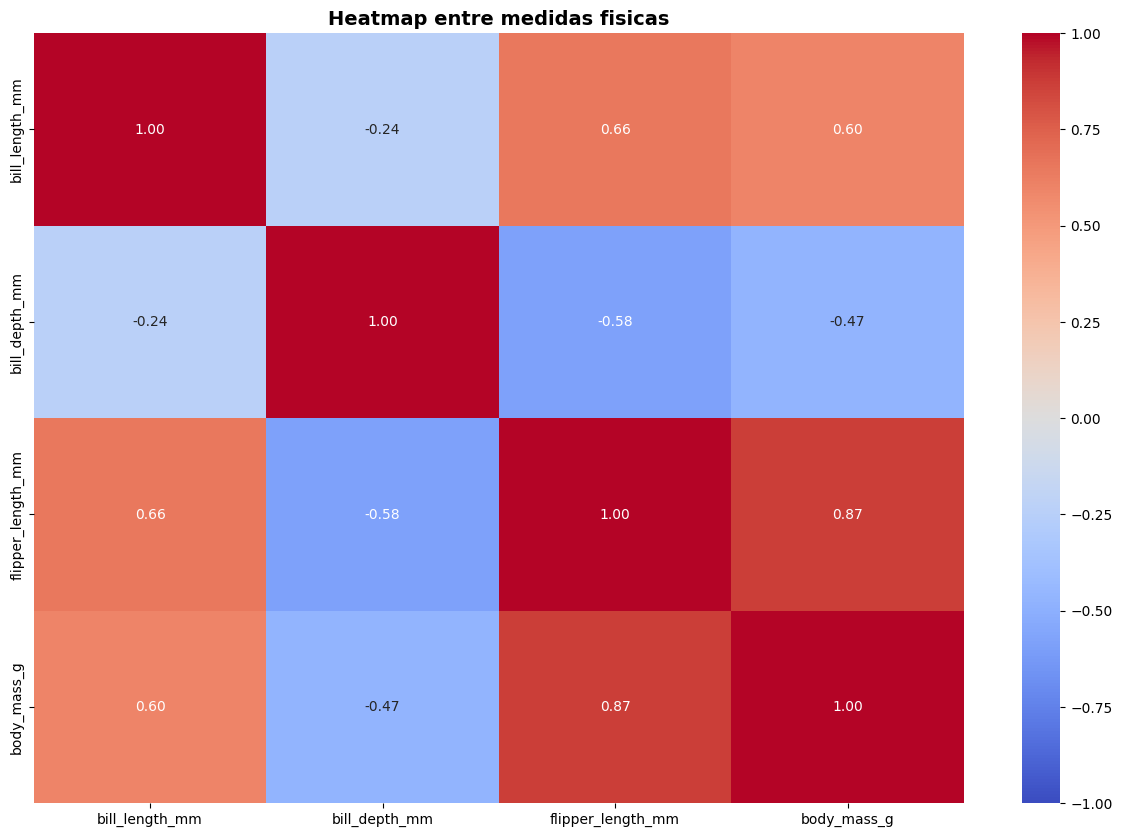

In [17]:
#recordemos que en la variable datos_numericos nos quedamos
#con el dataset filtrado, sin datos nulos
#.corr() calcula el coef de pearson
matriz_correlacion = datos_numericos.corr()
print("matriz de correlacion numerica")
display(matriz_correlacion)

#hacemos el heatmap
plt.figure(figsize=(15,10))

#annot=True: escribe el numero exacto dentro del cuadradito
# fmt=".2f"  : muestra solo 2 decimales para que no sea ilegible.
# cmap="coolwarm" : paleta de colores (rojo = positivo,azul = negativo).
# vmin=-1, vmax=1 : le decimos que el iímite de los colores es -1 y 1.
sns.heatmap(matriz_correlacion, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)

plt.title("Heatmap entre medidas fisicas", fontsize=14, fontweight='bold')
plt.show()



### Analasis de correlacion
- Correlaciones positivas: La relacion ,as fuerte (0,87) se da entre el peso y el largo de la aleta. Esto tiene logica ya que se puede entender que a mayor masa corporal el pinguino necesita aletas mas grandes y largas para impulsarse en el agu. Tambien vemos que el largo del pico tiene una relacion positiva con el tamaño del mismo (0,6 y 0,66)
- Correlaciones negativas: Aca hay un dato llamativo... la profundidad del pico tiene una correlacion negativa con todas las demas variables, siendo la mas fuerte con el largo de la aleta (-0,58). Esto indica algo bastante raro a primera vista, los pinguinos mas pesados y de aleta mas larga tienden a tener picos mas finitos.

Ahora me surge una duda... esto sera realmente asi dentro de cada especie por separado o es por que metimos en la misma bolsa una especie de pinguinios gigantes y de pico fino junto con otra enana de pico grueso?
Esto claramemte nos obliga a hacer graficos de dispersion  separando por especie para si ver si la tendencia negativa es real o es el producto de mezclar poblaciones distintas.

Primer veremos por especie la distribucion de cada rasgo fisico, separandolo por especie. Me gustaria identificar visualmente si dentro de una misma familia encontramos outliers.

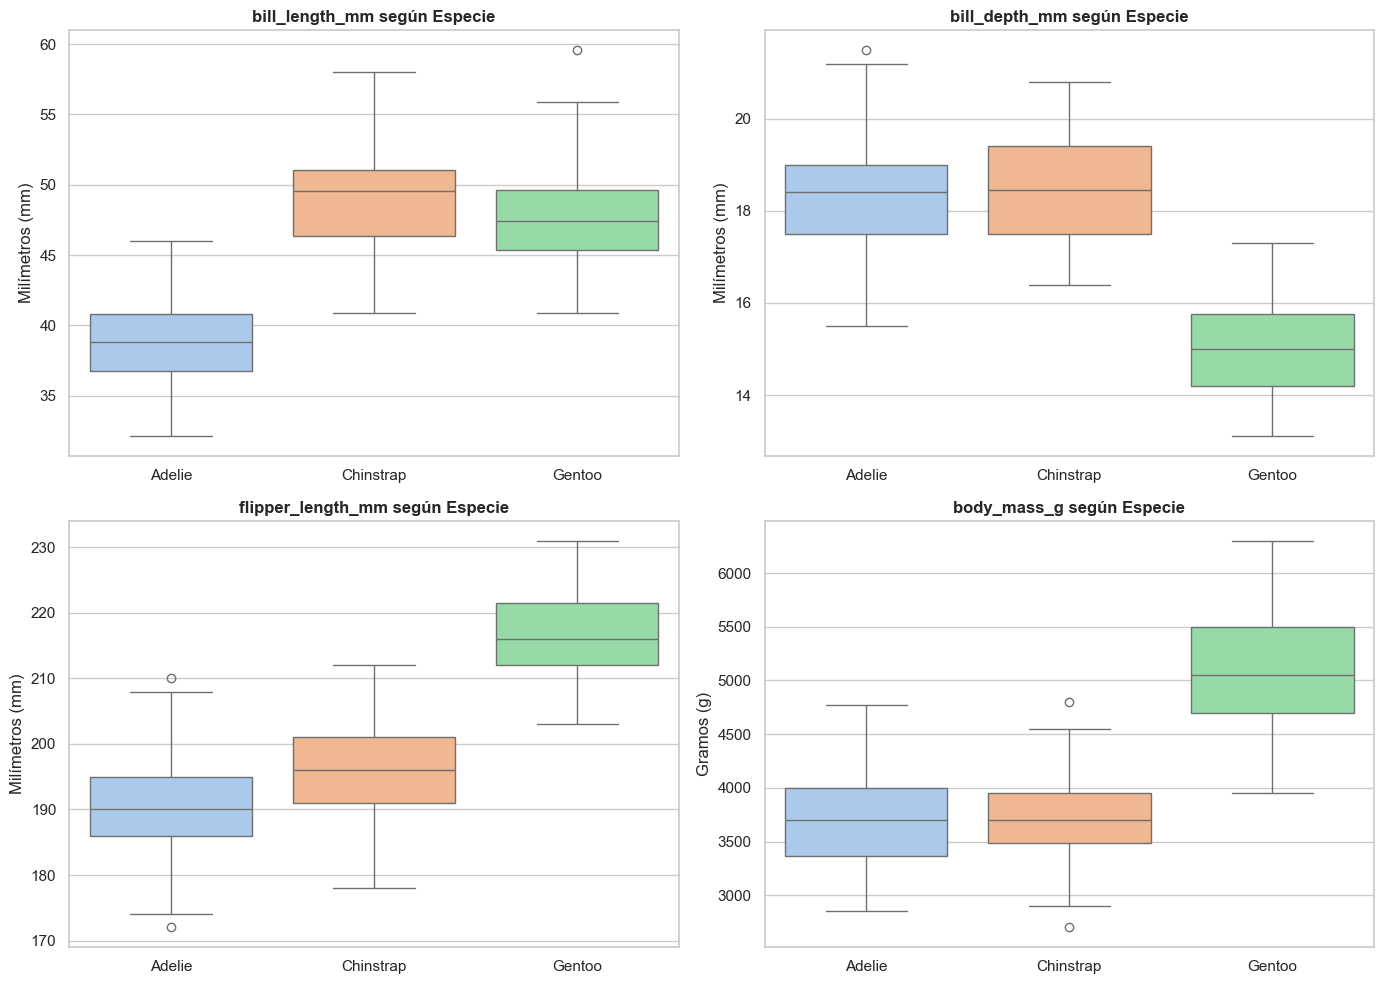

In [18]:
#usamos penguins_sexo para graficar pq tiene la columna 'species'

columnas_fisicas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']


plt.figure(figsize=(14, 10))
sns.set_theme(style="whitegrid", palette="pastel")


for i, columna in enumerate(columnas_fisicas, 1):
    plt.subplot(2, 2, i) 
    sns.boxplot(data=penguins_sexo, x='species', y=columna, hue='species', legend=False)
    plt.title(f"{columna} según Especie", fontsize=12, fontweight='bold')
    plt.xlabel("") #ocultamos la palabra 'species' del eje X
    
    if columna == 'body_mass_g':
        plt.ylabel("Gramos (g)")
    else:
        plt.ylabel("Milímetros (mm)")

plt.tight_layout()
plt.show()

    


curiosamente los gento tinene los picos menos profundos a pesar de dominar en tamaño de aleta y peso. Adelie y Chinstrap comparten rasgos similares de peso y profundidad del pico, pero el largo del pico es su principal diferenciador. Al segmentar tambien descubrimos outliers que el analisis global ocultaba, por ejemplo vemos un gentoo con un pico anormalmente largo y un chisntrap muy pesado para su especie.

Esto sirve como una advertencia para los proximos pasos, como los gentoo son los mas pesados/grandes pero tienen el pico mas chato, si calculamos correlaciones de forma global podemos encontrarnos con correlaciones espurias....

## 2.2

Scatterplot y lineas de tendencia: sirve para ver como se agrupan o dispersan los datos, si los puntos forman como una nube que sube hacia la deredcha, sabemos que hay una correlacion positiva. En ocasiones esta nube es muy ancha por lo que cuesta ver para donde va, con el comando "implot" calculamos la recta perfecta que atraviesa el centro de los puntos (es una regresion lineal) y la dibuja. Si la recta sube la correlacion es positiva

Vamos a graficar las dos relaciones mas fuertes que detectamos en el inciso anterior:
- La positiva mas alta (0,87): Aleta vs masa corporal
- La negativa mas alta (-0,58: profundidad del pico vs aleta)

En el primer grafico queremos analizar de manera global, todos los pinguinos sin separar por especie. Ya que simplemente queremos ver si a mayor masa , mas grande la aleta (es bastante logico creo yo).
Si separamos este grafico por especie, simplemente veriamos las 3 linas q apuntan para arriba

En el segundo grafico la historia cambia, quiero ver si es real que a meeida que un pinguino tiene la aleta mas grande o es mas peasdo, su pico se vuelve mas chato (es un poco contraintuivo). 

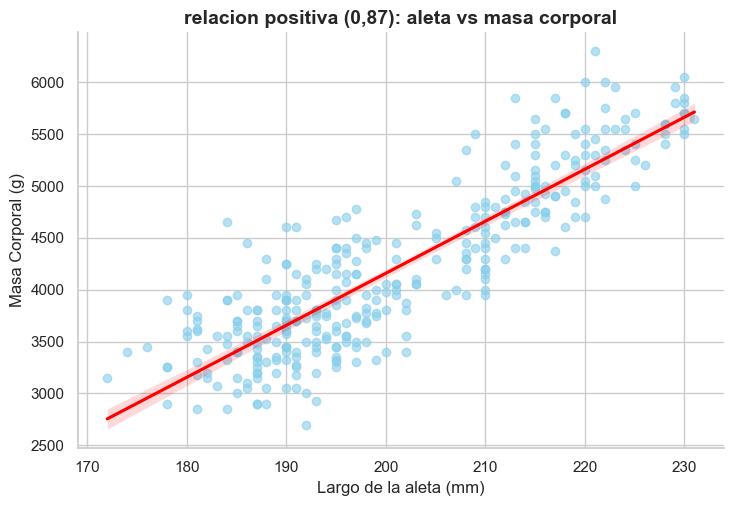

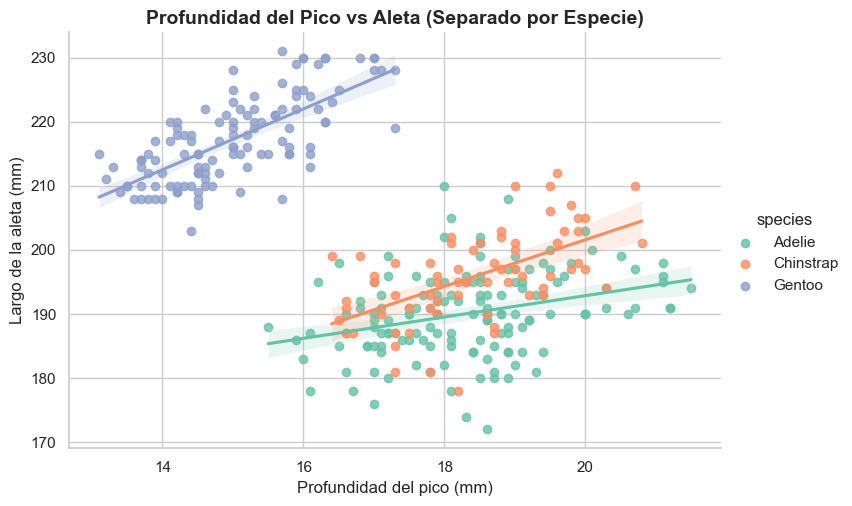

In [19]:
#relacion positiva

#lmplot calcula y dibuja la linea de tendencia y ademas llama a scatterplot
#usamos la variable penguins_sexo que es la que tiene los nulos eliminados y
#conserva la columna de las especies (ya que la de datos_numericos no la tiene)
grafico_positivo=sns.lmplot(data=penguins_sexo,x='flipper_length_mm',
                    y='body_mass_g',
                    scatter_kws={'alpha':0.6,'color':'skyblue'}, #puntos
                    line_kws={'color':'red'}, #linea de tendencia
                    aspect=1.5 #ensancha un poco el grafico (me quedaba feo y se lo pedi a la IA)
)

plt.title("relacion positiva (0,87): aleta vs masa corporal",fontsize=14,fontweight='bold')
plt.xlabel("Largo de la aleta (mm)")
plt.ylabel("Masa Corporal (g)")
plt.show()

#relacion negativa
#agregamos hue='species' (todo de la IA esto), para dibujar 3 nubes de puntos
#y 3 lineas de tendencia
grafico_negativo = sns.lmplot(
    data=penguins_sexo, 
    x='bill_depth_mm', 
    y='flipper_length_mm',
    hue='species',      # dividimos por especie
    palette='Set2',
    aspect=1.5
)
plt.title("Profundidad del Pico vs Aleta (Separado por Especie)", fontsize=14, fontweight='bold')
plt.xlabel("Profundidad del pico (mm)")
plt.ylabel("Largo de la aleta (mm)")
plt.show()

### Analisis de los resultados del analisis bivariados para variables numericas
Como conclusion inicial podemos decir que los numeros 'globales' pueden ser engañosos si no conocemos o intuimos la naturaleza o biologia de nuestros datos. Me hacia un poco de ruido pensar que si un pinguino era mas grande tenia el pico mas chato y el separar por especie permitio determinar que se debia a que simplemente el resultado global fue engañoso por que metimos a todas las especies en la misma bolsa.

- Aleta vs masa corporal: la nube de puntos y la linea de tendencia apunta clarmente hacia arriba y a la derecha, la conclusion es directa y aplica para todos los pinguinos por igual: A mayor longitud de aleta, mayor es la masa corporal del animal. Esta regla es puramente biologica y tiene todo el sentido.
- profundidad del pico vs aleta: Este fue nuestro descubriento hasta ahora, el hatmap ns advirtio que la relacion entre el grosor del pico y el largo de la aleta era fuertemente negativa,por lo que se podia pensar que aleta mas larga =pico mas fino. Gracias al segundo grafico verificamos que mi sospecha era cierta. Notamos que dentro de cada especie individual, la linea de tendencia apunta hacia ARRIBA. Gracias a natgeo y discovery podemos decir que biologicamente si el pinguino es mas grande, su pico tambien es mas grueso (la relacion interna por especie es positiva.)


## 2.3

### Correlaciones espurias y significancia

- La correlacion espuria es como una aparente asociacion o covarianza entre dos variables que no se dicta por una relacion causal o a una dependencia entre ellas. Es cmmo una falsa correlacion que tenemos debido a la omision de una tercer variable , que se conoce como variable de confusion. Por ejemplo cuando evaluamos las correlaciones -0,58 entre la profundidad del pico y la longitud de la aleta, pero se que esto se debe a que metimos a todas las especies en la misma bolsa, entonces podemos decir que la especie es la variable de confusion.

- Coef de pearson vs spearman: ambos cuantifican la asociacion entre dos variables pero tienen suposiciones distinas:
    - Pearson: evalua la fuerza y direccion de una relacion lineal, es el cociente entre la covarianza y el producto de sus desviaciones estandar. Asume que los datos provienen de una distribucion normal bivariada, varianza constante y es sensible a valores atipicos
    - Correlacion de rangos de Spearman: evalua relaciones donde por ejemplo, si X aumenta, Y aumenta o disminuye pero no necesariamente a una tasa constante o lineal. Es una prueba no parametrica. Al depender de rangos y no de valores brutos de la escala, es inmune a las distribuciones no normales y robuso frente a outliers.




In [20]:
from scipy.stats import pearsonr,spearmanr

#machete mio pq me perdi con el nombre de las variables:
#datos_numericos tiene solo las 4 columnas numericas y borro las 2 filas que no tenian medidas fisicas
#penguins_sexo tiene todas las columnas pero borro las 11 filas de los que no tenian el sexo

#obtenemos las variables numericas
columnas_fisicas=datos_numericos.columns

#hipotesis
print("=== PRUEBA DE HIPÓTESIS: CORRELACIÓN DE PEARSON ===")
print("Hipótesis Nula (H0): NO existe correlación matemática entre las variables.")
print("Hipótesis Alternativa (H1): SÍ existe correlación matemática entre las variables.")
print("Nivel de significancia (Alfa): 0.05")
print("-"*50)
#cruzamos todas las variables contra todas, significancia de 0,05
for i in range(len(columnas_fisicas)):
    for j in range(i+1,len(columnas_fisicas)):
        col1=columnas_fisicas[i]
        col2=columnas_fisicas[j]
        #parsonr devuelve el coef de pearson y el p-valor
        coef,p_valor=pearsonr(datos_numericos[col1],datos_numericos[col2])
        print(f"Relación: {col1} vs {col2}")
        print(f"Coeficiente: {coef:.3f}")
        print(f"P-valor: {p_valor:.3e}")

        if p_valor < 0.05:
            print("relacion significativa")
        else: 
            print("relacion NO  significativa")
        print("-"*50)



=== PRUEBA DE HIPÓTESIS: CORRELACIÓN DE PEARSON ===
Hipótesis Nula (H0): NO existe correlación matemática entre las variables.
Hipótesis Alternativa (H1): SÍ existe correlación matemática entre las variables.
Nivel de significancia (Alfa): 0.05
--------------------------------------------------
Relación: bill_length_mm vs bill_depth_mm
Coeficiente: -0.235
P-valor: 1.120e-05
relacion significativa
--------------------------------------------------
Relación: bill_length_mm vs flipper_length_mm
Coeficiente: 0.656
P-valor: 1.744e-43
relacion significativa
--------------------------------------------------
Relación: bill_length_mm vs body_mass_g
Coeficiente: 0.595
P-valor: 3.808e-34
relacion significativa
--------------------------------------------------
Relación: bill_depth_mm vs flipper_length_mm
Coeficiente: -0.584
P-valor: 1.233e-32
relacion significativa
--------------------------------------------------
Relación: bill_depth_mm vs body_mass_g
Coeficiente: -0.472
P-valor: 2.277e-20
rel

### Analisis de las pruebas de pearson
Matematicamente la prueba valida todas las relaciones como estadisticamente significativas, pero sabemos que por el analisis visual que hicimos anteriormente, la corerelacion profundidad del pico vs aleta es una CORRELACION ESPURIA. Este falso resultado se debe pq omitimos la variable de confusion en el calculo general, que se entiende que es la "especie".

Esto demuestra que la significancia estadistica valida que los numeros se mueven juntos, pero carece de contexto biologico, es como lo de los helados y el ataque de tiburones, si calculas la correlacion te va a dar fuertemente positiva pero es fuera de contexto, la variable de confusion ahi seria el "verano"

## 2.4

Vamos a comparar exclusivamente el alrgo del pico contra la profundidad o grosor del mismo, la correlacion global de estas variables es de -0,24, es decir, a primera vestia un pico mas largo es mas finito.
Lo interesenta aca es que veamos que pasa al separar por especie, pero ya intuimos con el analisis y conclsuion que hice antes lo que va a pasar

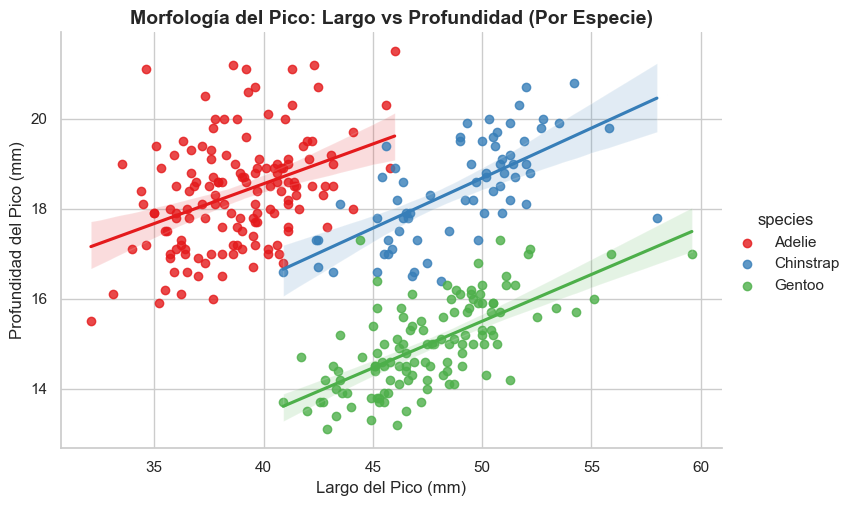

In [21]:
#X=largo del pico
#Y=profundidad del pico
sns.lmplot(
    data=penguins_sexo, 
    x='bill_length_mm', 
    y='bill_depth_mm', 
    hue='species',      
    palette='Set1', # Paleta de colores primarios para diferenciarlos bien
    aspect=1.5         
)

plt.title("Morfología del Pico: Largo vs Profundidad (Por Especie)", fontsize=14, fontweight='bold')
plt.xlabel("Largo del Pico (mm)")
plt.ylabel("Profundidad del Pico (mm)")
plt.show()


### Analisis de la relacion entre 'bill_length_mm' y 'bill_depth_mm'

- Nuevamente nos encontramos con que el analisis de manera global nos da un dato engañoso.
Como dijimos, la correlacion era de -0.24... si en este grafico quitamos los colores y las rectas, al ver los puntos trazariamos una recta descendente desde los puntos agrupados arriba hacia los de abajo. La conclusion seria, a medida que el pico crece a lo largo, se hace mas chato.

- Descubrimos que segmentar los datos y codificando por color , se identifican los 3 clsuters perfectamente definidos:
    - Adelie = picos muy cortos pero muy gruesos
    - Gentoo = el extremo opuesto, picos largos pero muy finitos
    - Chisntrap =son el punto medio, picos largos como los Gentoo pero gruesos como los adelie

- Conclusion: entiendo que como las 3 lineas de tendencia apuntan para arriba, por lo que se demuestra que dentro de una misma especie el crecimiento es proporcional y constante (correlacion positiva): si un pinguino tiene un pico mas largo que el promedio de su familia, ese pico tambien sera mas grueso. El -0.24 negativo del Heatmap es simplemente una Correlación Espuria generada al promediar juntas las especies diferentes.

**Con esto dejamos en evidencia la paradoja de simpson**

## reporte del analisis bivariado
- la asociacion mas confiable es la relacion lineal positiva entre el largo de la aleta y la masa corporal, es una regla biologica constante en toda la poblacion.
- la variable predictora principal es el largo de la aleta ('flipper_length_mm'). Creo que es la que mas potencial tiene para estimar el peso de un individuo sin tener en cuenta su especie.
- la variable 'species' es la predictora que relaciona el tamaño y grosor del pico, cualquier modelo predictivo va a funcionar mal si no tiene estratifica los datos utilizando la especie como condicionante.
- Si el objetivo futuro fuera entrenar un modelo de clasificación para adivinar la especie de un pingüino desconocido, vimos que la profundidad del pico y el largo del mismo diferenciaba muy bien a los grupos, basicamente es un clasificador natural

# Ejericio 3: analisis multivariado y visualizacion avanzada

## 3.1

matriz de dispersion para visualizar las relaciones por pares entre variables numericas

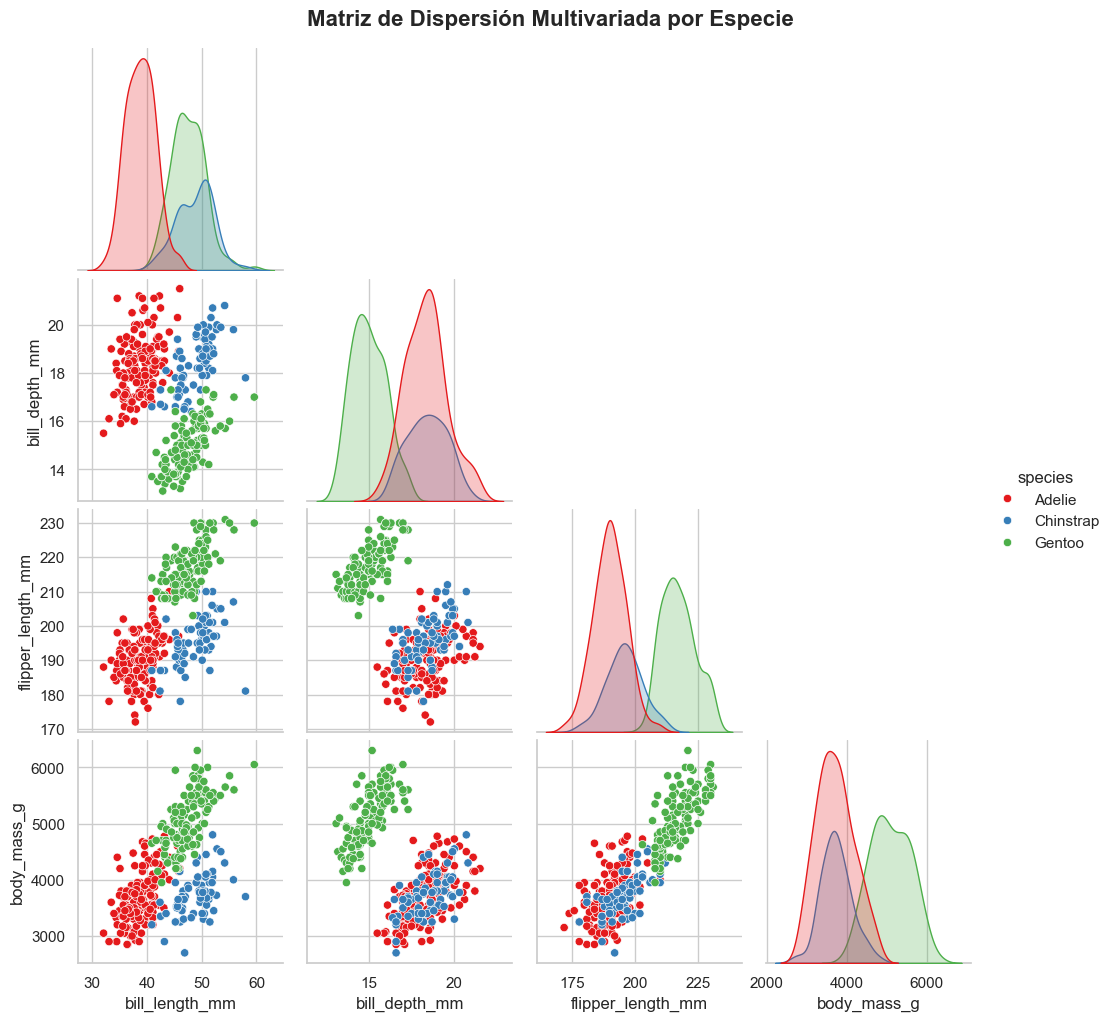

In [22]:
# El comando pairplot genera la matriz completa
grafico_matriz = sns.pairplot(
    data=penguins_sexo, 
    hue='species',    #el componente multivariado: separamos por especie
    palette='Set1', 
    diag_kind='kde',  #en la diagonal mostrara campanas de distribucion (densidad)
    corner=True         #borra la mitad superior para no mostrar graficos duplicados
)

grafico_matriz.fig.suptitle("Matriz de Dispersión Multivariada por Especie", y=1.02, fontsize=16, fontweight='bold')
plt.show()


- Basicamente es hacer el analisis bivariado completo en un solo bloque de codigo, condensa todas las relaciones bivariadas posibles y univariadas , estratificando por la variable especies.

- Sobre la diagonal principal: Las curvas de densidad (KDE) nos confirman los hallazgos  que hice antes en el analisis univariado.
- En los graficos de dispersion notamos que la variable discriminadora principal es bill_length, aisla perfectamente a los adelie (mirando su distribucion univariada) y como chisntrap y gentoo difieren mucho en sus metricas fisicas, cruzar el largo del pico con cualquier otra variable numerica de la matreiz, logra generar tres clusteres muy bien diferenciables. Esto demuestra que seguimos evolucionando en el analsiis, antes no me di ni cuenta de esto y me parece bien que asi sea, en el reporte del ej2 puse que la predictora ideal era el largo de la aleta....



## 3.2

### grafico de coordenadas paralelas.

- pide datos normalizados por que si intentamos graficar el peso en gramos (por ej 5000) y la profundidad del pico en mm (ponele que 20mm), el grafico seria malisimo.
    - normalizamos haciendo que todos los numeros de todas las columnas esten entre 0 y 1. para esto usamos minmaxscaler de sklearn

me pregunto... que busca este grafico? 
- ahora cada pinguino es una linea continua y sirve para descubrir los "perfiles" de cada uno. Si una especie comparte las mismas proporciones fisicas, todas las lineas viajaran juntas formando una "ruta" del mism color. Si las lineas de diferente color se cruzan y forman una X entre 2 variables, es el indicador visual que nos dice que la correlacion es inversa.






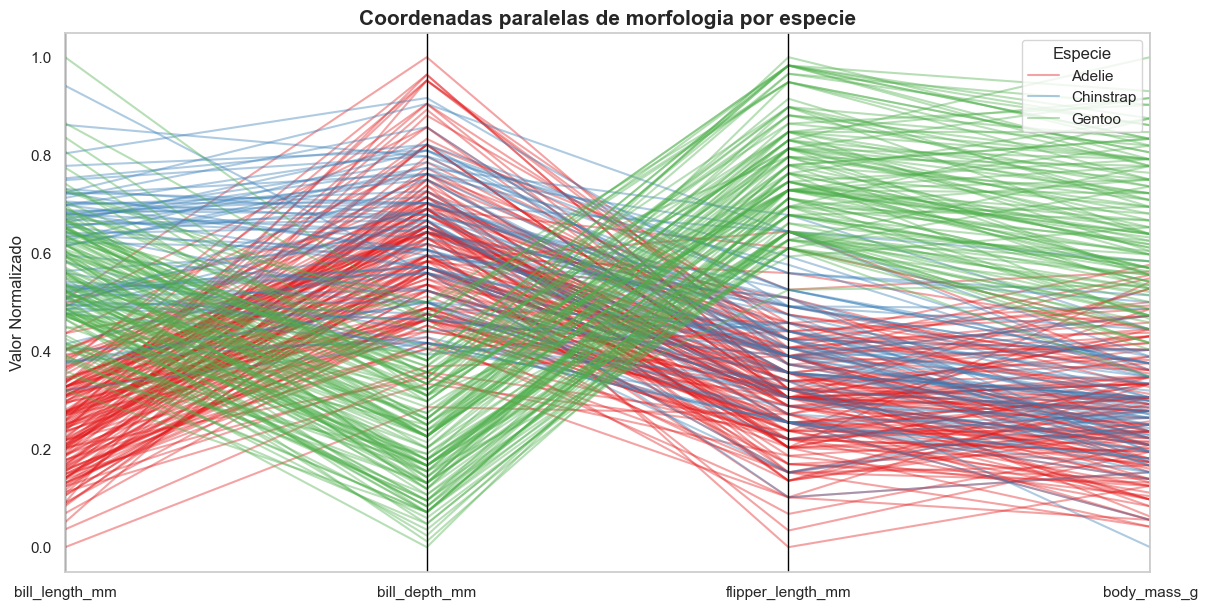

In [23]:
from pandas.plotting import parallel_coordinates
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt

columnas_fisicas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

#por las dudas hacemos una copia del dataset para no alterar los datos originales
df_paralelo=penguins_sexo[columnas_fisicas + ['species']].copy()
#normalizamos
escalador = MinMaxScaler()
df_paralelo[columnas_fisicas] = escalador.fit_transform(df_paralelo[columnas_fisicas])

#grafico de coordenadas paralelas
plt.figure(figsize=(14, 7))
parallel_coordinates(
    df_paralelo, 
    class_column='species', 
    color=['#e41a1c', '#377eb8', '#4daf4a'], #rojo, azul y verde para mantener consistencia
    alpha=0.4
)

plt.title("Coordenadas paralelas de morfologia por especie", fontsize=15, fontweight='bold')
plt.ylabel("Valor Normalizado", fontsize=12)
plt.xticks(fontsize=11)
plt.legend(title="Especie", loc='upper right')

### analisis del grafico de coordenadas paralelas por especie
- Los gentoo tienen el patron mas identificable, ademas podemos ver claramennte la caida que tienen en la profundidad del pico y despues suben hadcia el tope en aleta y peso... ese patron en "V" es como la "firma" de los Gentoo. Tambien para relacionarlo con lo que hice y dije antes, ese cruce de lineas verdes subiendo mientras las otras bajan explica lo de las correlaciones espurias globales...

- La firma de los Adelie es el camino casi opuesto a los Gentoo en su cabeza, arrancan lo mas abajo posible del largo del pico, suben a la parte superior en profundidad y luego caen a la parte baja de la aleta y peso.

- Con respecto a los Chinstrap... este grafico muestra por que se mezclaban en los scatter plots, tienen un perfil bastante hibrido. Comparten el inciio de los Gentoo pero luego no caen, se mantienen altos en profundidad del pico y se mezclan con los Adelie y a partir de ahi comparten la misma ruta que estos.


## 3.3

### heatmaps de correlacion segmetnados por especie.

basicamente va a mostrar en un grafico todo lo que dijimos anteriormente sobre las correlaciones. gaste mucho tiempo analizando lo anterior un poco al pepe pq aca lo vamos a ver bien sencillo.



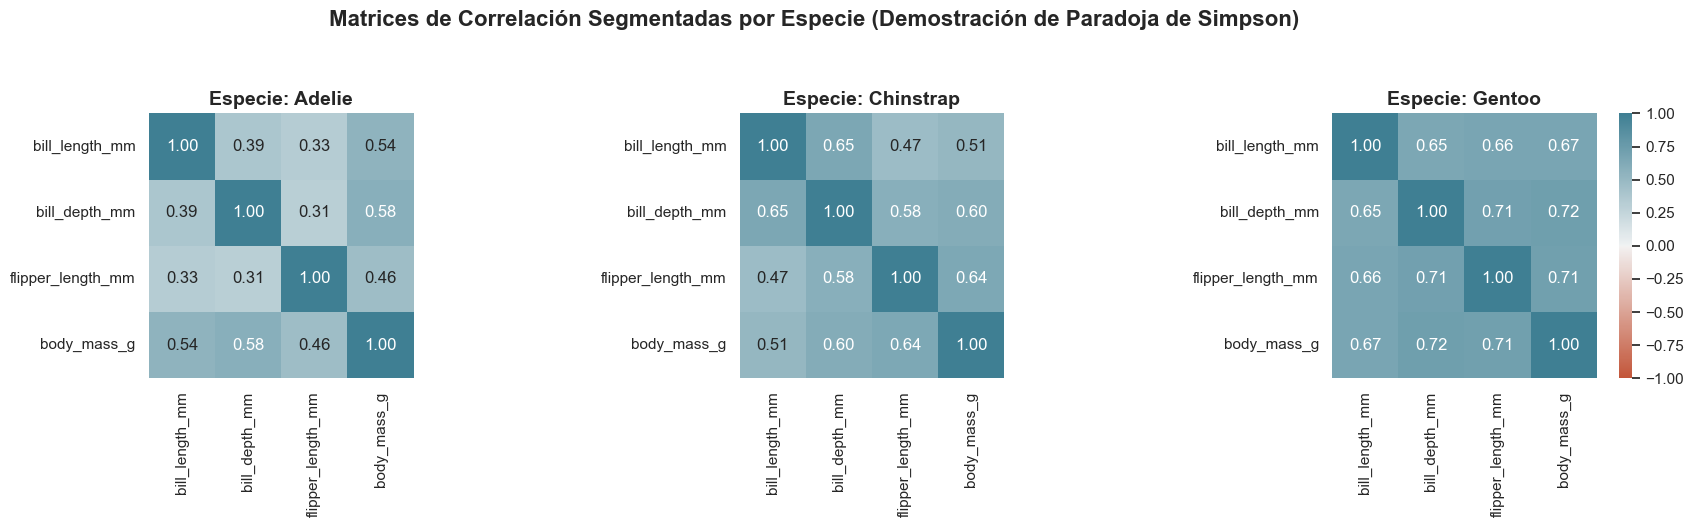

In [24]:
#extraemos las 3 especies
especies = penguins_sexo['species'].unique()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# rojo para negativo, azul para positivo
cmap = sns.diverging_palette(20, 220, as_cmap=True)

for i, especie in enumerate(especies):
    
    # filtramos el dataset para quedarnos SOLO con los pingüinos de esta especie
    datos_especie = penguins_sexo[penguins_sexo['species'] == especie]
    
    #calculamos la matriz
    matriz_corr_interna = datos_especie.select_dtypes(include=[np.number]).corr()
    
    #dibujamos el heatmap
    sns.heatmap(matriz_corr_interna, 
                ax=axes[i], 
                annot=True, #muestra los numeros
                fmt=".2f",   #2 decimales
                cmap=cmap, 
                vmin=-1, vmax=1, #congelamos la escala para que los 3 graficos sean giualitod
                cbar=(i == 2),
                square=True) 
    
    axes[i].set_title(f"Especie: {especie}", fontsize=14, fontweight='bold')
    if i > 0:
        axes[i].set_ylabel("")

plt.suptitle("Matrices de Correlación Segmentadas por Especie (Demostración de Paradoja de Simpson)", 
             fontsize=16, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()


### Analisis de los heatmap
Confirmamos todo lo anterior... no hay ni un color rojo, ni una corelacion negativa. Desmentimos el heatmap del ejercicio 1
Al aislar las poblaciones, descubrimos que **todas las variables físicas tienen una correlación estrictamente positiva** ,Las correlaciones espurias negativas descubiertas se invirtieron.



## 3.4

### agrupamiento de variables para identificar grupos de caracteristicas morfologicas relacionadas

El objetivo de agrupar variables es encontrar grupos de pinguinos parecidos, y a su vez, encontrar redundancia de informacion... para osea las reordenamos poniendo juntas las que se comportan parecido. Si dos variables tienen mucha correlacion, brindan la misma informacion... por lo que el dendograma las agrupara en la misma rama del arbol.

Basicamente hay que transformar la matriz de corelacion en una matriz de distancia. Si la correlacion es de 1 (misma variable), la distancia sera 0. La formula es **Distancia = 1 - correlacion**


MATRIZ DE DISTANCIA


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,0.000,0.771,0.347,0.411
bill_depth_mm,0.771,0.000,0.422,0.528
flipper_length_mm,0.347,0.422,0.000,0.127
body_mass_g,0.411,0.528,0.127,0.000


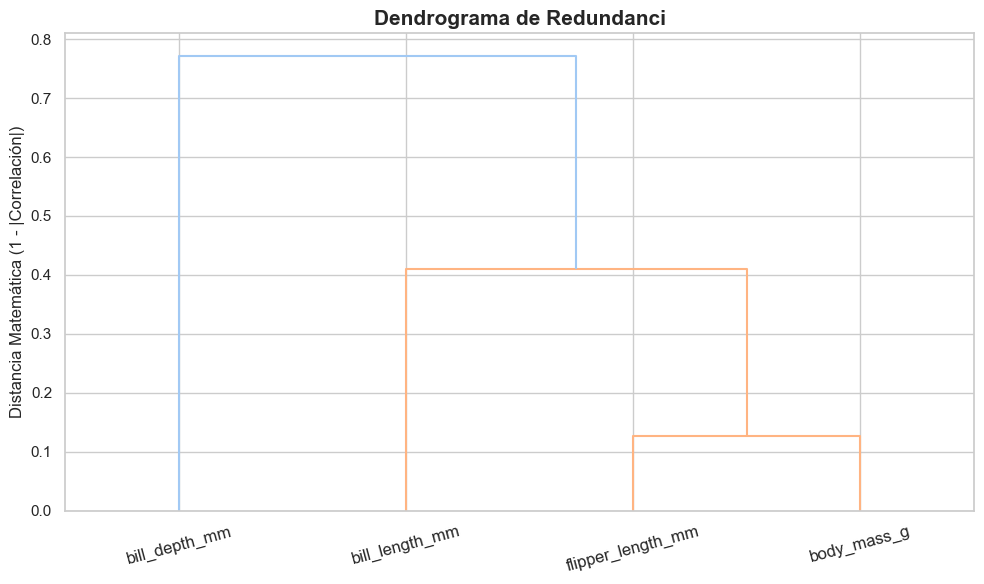

In [25]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

matriz_correlacion = penguins_sexo.select_dtypes(include=[np.number]).corr()

#transofrmamos esta correlacion en distancia
matriz_distancia=1-np.abs(matriz_correlacion)
#forzamos la diagonal a ser 0, si no quedaba 0,00000000000000
np.fill_diagonal(matriz_distancia.values,0)

#mostramos la matriz de distancias
print("MATRIZ DE DISTANCIA")
display(matriz_distancia.round(3))

#esto me lo hizo la ia pq no me quedaba , me daba error y ni idea por que era, es como que scipy pedia un vector
distancia_condensada=squareform(matriz_distancia)

#agrupamiento,'complete' calcula la distancia maxima entre cluster para unir
agrupamiento=linkage(distancia_condensada,method='complete')

#dibujamos el dendograma
plt.figure(figsize=(10, 6))
dendrogram(
    agrupamiento,
    labels=matriz_correlacion.columns, # Usamos los nombres 
    leaf_rotation=15,           
    leaf_font_size=12,
    color_threshold=0.5    #colorea las ramas para resaltar los grupos muy unidos
)

plt.title("Dendrograma de Redundanci", fontsize=15, fontweight='bold')
plt.ylabel("Distancia Matemática (1 - |Correlación|)", fontsize=12)
plt.tight_layout()
plt.show()

### analiss de la matriz de distancia y del dendograma
Sirve para descubrir las redundancias morfologicas, un valor cercano a 0 en la matriz de distancia, indica que las variables "miden" lo mismo.
- La distancia entre el largo de la aleta y la masa corporal es la mas baja de todas (0,127), el dendograma lo refleja enj el primer puente o escalon, y la altura desde el eje X hacia el escalon es de justamente 0,127. La conclusion de este resultado es que el largo de la aleta y el peso son variables redundantes, ambas miden el tamaño general del pinguino.
- el largo del pico seria como la variable interna, se une al cluster principal un poco mas arriba , a una altura de (0,411). Esto indica que el largo del pico tiene cierta relacion con el tamaño general del ave, pero aporta informacion propia como para no considerarlo redundante al peso o a la aleta.
- La variable mas independiente de todas es la profundidad del pico, su distancia al eje X es de 0,77, la conclusion de esto es que el grosor del pico es la caracteristica morfologica mas independiente, no esta atada al tamaño general del pinguino (lo comprobamos sabiendo que el gentoo son los pinguinos mas grandes pero tienen los picos mas finos)

En caso de tener problemas de dimensionalidad, este dendograma nos ayudaria a simplificar el analisis para descartar variables, ya que tranquilamente podriamos eliminar o el largo de la aleta o la masa corporal.

## 3.5

### spider plot para comparar variables morfologicas promedio entre especies

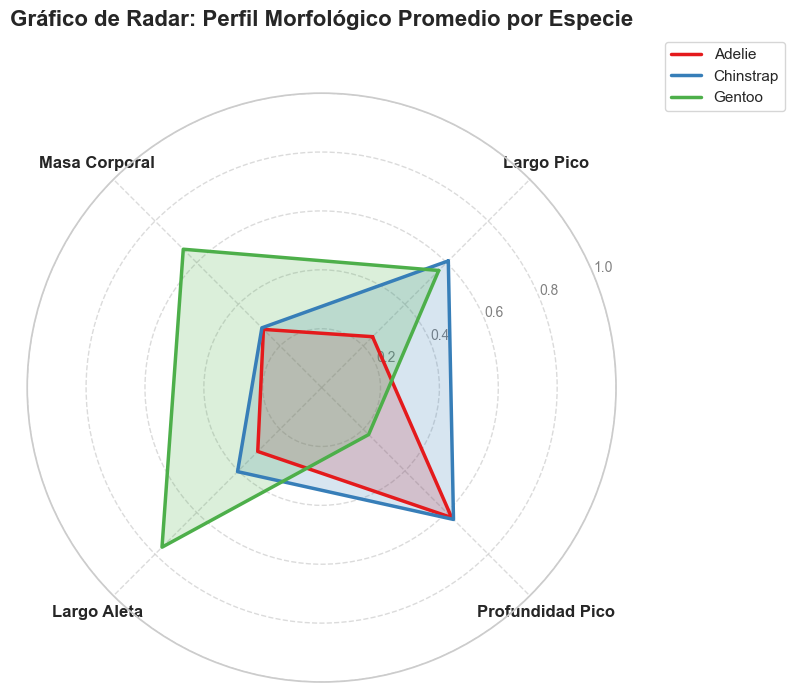

In [26]:
from sklearn.preprocessing import MinMaxScaler
columnas_fisicas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

#normalizamos
escalador = MinMaxScaler()
datos_normalizados = penguins_sexo.copy()
datos_normalizados[columnas_fisicas] = escalador.fit_transform(penguins_sexo[columnas_fisicas])

#PROMEDIOS
promedios_norm = datos_normalizados.groupby('species')[columnas_fisicas].mean()

#de aca en adelante lo hizo la IA
angulos = np.linspace(0, 2 * np.pi, len(columnas_fisicas), endpoint=False).tolist()
angulos += angulos[:1] # Repetimos el primer ángulo al final para cerrar el polígono

#preparamos el lienzo en modo Polar (Circular)
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
colores = ['#e41a1c', '#377eb8', '#4daf4a'] # Rojo, Azul, Verde

#Iteramos sobre las especies para dibujar
for idx, especie in enumerate(promedios_norm.index):
    # Extraemos valores y cerramos el polígono
    valores = promedios_norm.loc[especie].tolist()
    valores += valores[:1] 
    
    # Dibujamos línea y rellenamos
    ax.plot(angulos, valores, color=colores[idx], linewidth=2.5, label=especie)
    ax.fill(angulos, valores, color=colores[idx], alpha=0.20) # 20% de opacidad

#ESTÉTICA DEL RADAR
ax.set_theta_offset(np.pi / 4) # Rota el gráfico 45 grados para que parezca una cruz perfecta [+]
ax.set_theta_direction(-1)     # Dibuja los ejes en sentido horario

# Nombres de los vértices exteriores
etiquetas = ['Largo Pico', 'Profundidad Pico', 'Largo Aleta', 'Masa Corporal']
ax.set_xticks(angulos[:-1]) 
ax.set_xticklabels(etiquetas, fontsize=12, fontweight='bold') 

#LOS ANILLOS CONCÉNTRICOS INTERIORES
ax.set_ylim(0, 1.0) # Forzamos que el borde exterior sea el 1.0
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0]) # Dibujamos un círculo cada 0.2
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=10, color='gray') # Texto de los círculos
ax.grid(True, linestyle='--', alpha=0.7) # Hacemos que la red sea punteada
# ---------------------------------------------

plt.title("Gráfico de Radar: Perfil Morfológico Promedio por Especie", size=16, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()


### Analisis del spider plot

nos permite visualizar las medidas morfologicas de cada especie como un "perfil estadistico", y nos ayuda a facilitar la comparacion de las proporciones de cada medida
- En la espcie gento, el poligono se estira mucho hacia la izquierda (largo de la aleta) y hacia arriba a la izq(masa corporal), pero esta contraido en direccion a la profundidad del pico, es un grandote de pico chico ???????????????????????????????

- Los chinstrap es la especie que mas largo tiene el picoy mantiene altos niveles de profundidad del mismo, pero son pequeños a comparacion del gentoo en masa y largo de la aleta, son medianos de picos largos y anchos???????????????????? QUE MANDANNNNN

- el poligono de los adelie es el mas chiquito de todos, todo se mantiene cerca del centro y solo destacan en la profundidad del pico. Son chiquitos y compactos en todos los sentidos pero tienen el pico ancho ???



## CONCLUSION EJERCICIO 3

El analisis multivariado me ayudo a identificar que el datset presenta una fuerte redundancia interna  que puede llevar a conclusiones erroneas si no se estratifica. 
- Teniamos correlaciones espurias (paradoja de simpson, esta en la teoria y lo busque por las dudas), ya que habia correlaciones negativas falsas y al segmentar por especie nos dimos cuentas que estas correlaciones eran todas positivas dentro de cada familia de pinguinos, entonces concluimos que el aumento de cualquier medida fisica acompaña proprocionalmente el aumento de las demas.

- Tambien detectamos una redundancia que lo comprobamos gracias al dendograma, ya que el largo de la aleta y la masa corporal estaban muy correlacionadas, se puede decir que se pueden unir en una sola variable que podriamos llamar "tamaño corporal"

- Con las coordenadas paralelas y el spider plot identificamos el "perfil" o "firma" de cada especie, revelando que niguna es una version mas chiquita o mas grande que la otra.

- Sigo pensando que el cruce bivariado entre el largo del pico y la profundidad del mismo es el patron mas discriminante del conjunto de datos, divide a cada especie en tres cluster con muy poco solapamiento.

# EJERCICIO 4 : muestreo y reduccion de dimensionalidad

## 4.1

### estrategias de muestreo

species,Adelie,Chinstrap,Gentoo
1. Población Original,43.8,20.4,35.7
2. Muestreo Proporcional,43.3,20.0,36.7
3. Muestreo Balanceado,33.3,33.3,33.3
4. Muestreo Aleatorio,46.7,21.7,31.7


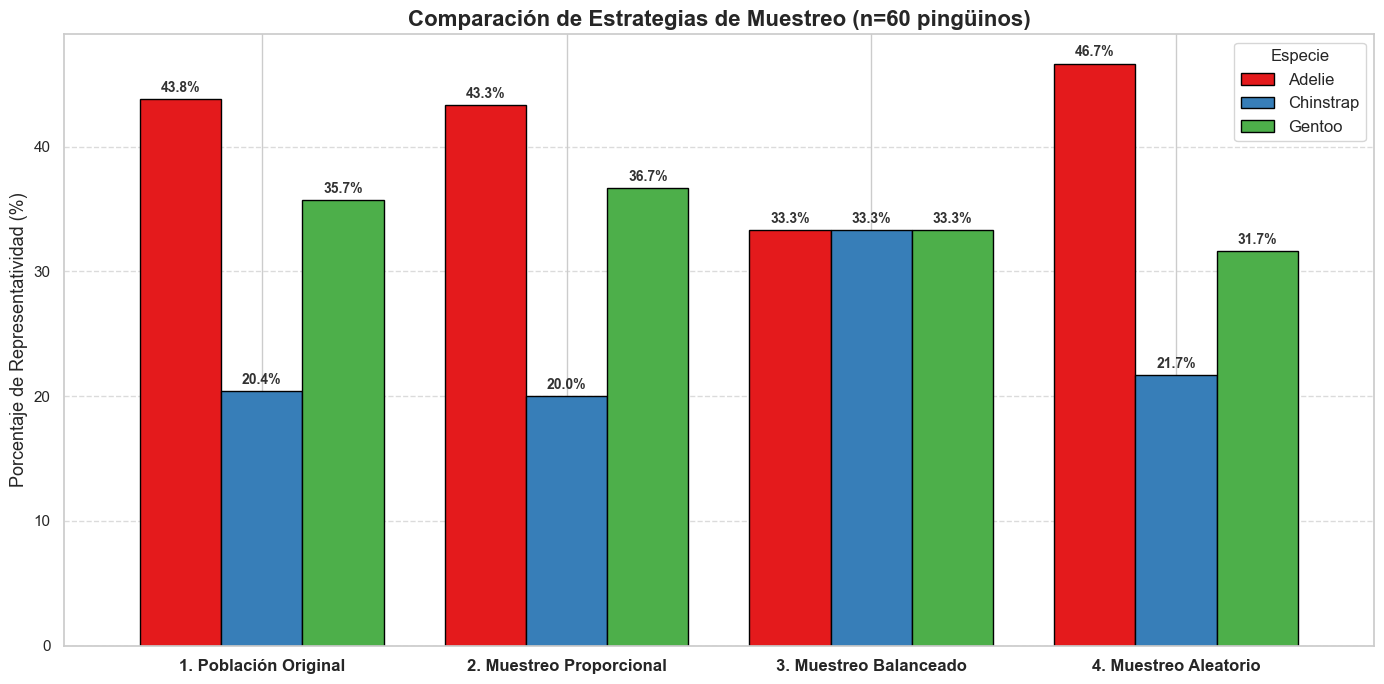

In [27]:
from sklearn.model_selection import train_test_split
semilla=42
tamaño=60

df_original=penguins_sexo.copy()
#muestreo simple
m_simple=df_original.sample(n=tamaño,random_state=semilla)

#muestreo estratificado proporcional
m_proporcional,_=train_test_split(
        df_original,
        train_size=tamaño,
        stratify=df_original['species'],
        random_state=semilla)

#muestreo estratificado balanceado, obliga a extraer 20 de cada raza
m_balanceada=df_original.groupby('species').sample(n=(tamaño//3),random_state=semilla)

#calculos de porcentajes (se lo pedi a la IA)
prop_orig = df_original['species'].value_counts(normalize=True) * 100
prop_simp = m_simple['species'].value_counts(normalize=True) * 100
prop_prop = m_proporcional['species'].value_counts(normalize=True) * 100
prop_bala = m_balanceada['species'].value_counts(normalize=True) * 100

#dibujos de la tabla y graficos
df_comparacion = pd.DataFrame({
    '1. Población Original': prop_orig,
    '2. Muestreo Proporcional': prop_prop,
    '3. Muestreo Balanceado': prop_bala,
    '4. Muestreo Aleatorio': prop_simp
}).fillna(0).T # Transponemos para que las estrategias sean el eje x

display(df_comparacion.round(1))

fig, ax = plt.subplots(figsize=(14, 7))
# Dibujamos las barras agrupadas
df_comparacion.plot(
    kind='bar', ax=ax, 
    color=['#e41a1c', '#377eb8', '#4daf4a'], 
    edgecolor='black', width=0.8
)

plt.title("Comparación de Estrategias de Muestreo (n=60 pingüinos)", fontsize=16, fontweight='bold')
plt.ylabel("Porcentaje de Representatividad (%)", fontsize=13)
plt.xticks(rotation=0, fontsize=12, fontweight='bold')
plt.legend(title="Especie", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Le ponemos el numerito del porcentaje en el techo de cada barra
for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(f'{altura:.1f}%', 
                    (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333', 
                    xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.show()


# 4.2

### PCA manteniendo el 95% de varianza explicada

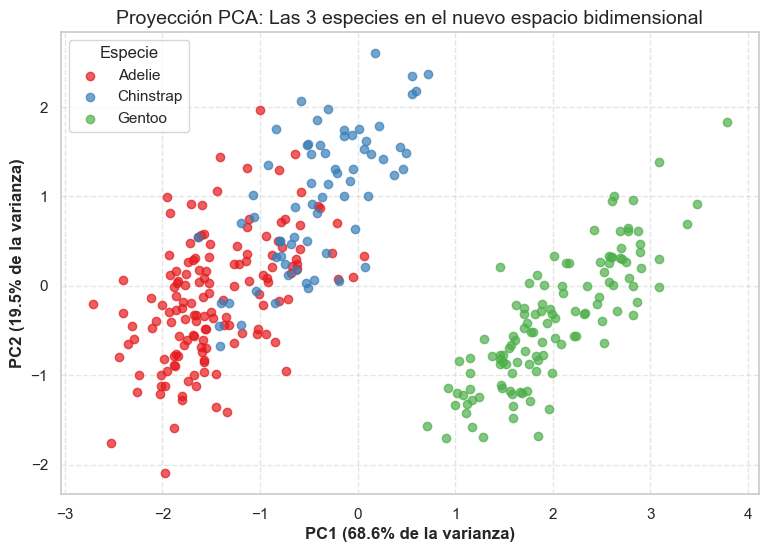

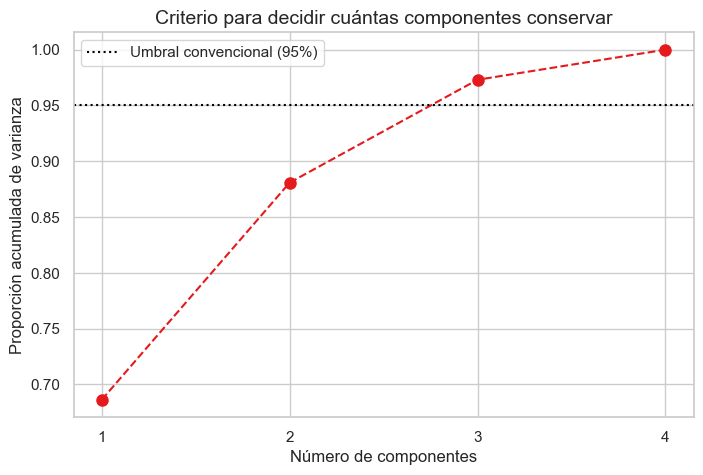

REDUCCIÓN DE DIMENSIONALIDAD
Dimensiones Originales (Columnas físicas): 4
Nuevas Dimensiones Necesarias (para >95% varianza): 3
Varianza exacta conservada: 97.30%


In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
#estandarizacion, reutilizamos penguins_sexo y colmunas_fisicas
Xz=StandardScaler().fit_transform(penguins_sexo[columnas_fisicas])
#PCA
pca=PCA().fit(Xz)
proyeccion=pca.transform(Xz) #z=Xb , y_hat=xz ... espacio original aprox del dataset original
var=pca.explained_variance_ratio_

plt.figure(figsize=(9, 6))
colores = {'Adelie': '#e41a1c', 'Chinstrap': '#377eb8', 'Gentoo': '#4daf4a'}

for especie in penguins_sexo["species"].unique():
    sel = (penguins_sexo["species"] == especie).to_numpy()
    plt.scatter(proyeccion[sel, 0], proyeccion[sel, 1], alpha=0.7, label=especie, color=colores[especie])

plt.xlabel(f"PC1 ({var[0]:.1%} de la varianza)", fontweight='bold')
plt.ylabel(f"PC2 ({var[1]:.1%} de la varianza)", fontweight='bold')
plt.title("Proyección PCA: Las 3 especies en el nuevo espacio bidimensional", fontsize=14)
plt.legend(title="Especie")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(var) + 1), var.cumsum(), marker="o", linestyle="--", color='#e41a1c', markersize=8)
plt.axhline(0.95, color="black", linestyle=":", label="Umbral convencional (95%)")
plt.xlabel("Número de componentes", fontsize=12)
plt.ylabel("Proporción acumulada de varianza", fontsize=12)
plt.xticks(range(1, len(var) + 1))
plt.title("Criterio para decidir cuántas componentes conservar", fontsize=14)
plt.legend()
plt.show()

pca_optimo = PCA(n_components=0.95)
Xz_reducido = pca_optimo.fit_transform(Xz)

print("REDUCCIÓN DE DIMENSIONALIDAD")
print(f"Dimensiones Originales (Columnas físicas): {Xz.shape[1]}")
print(f"Nuevas Dimensiones Necesarias (para >95% varianza): {Xz_reducido.shape[1]}")
print(f"Varianza exacta conservada: {np.sum(pca_optimo.explained_variance_ratio_)*100:.2f}%")


### Analisis del PCA
PC1 y PC2 son la variable principal 1 y la 2, PCA agarra las 4 columnas y crea variables nuevas. PC1(e eje X), es la primera variable creada, es la que captura la mayor varianza explicada, podemos intuir que la PC1 representa el tamaño general del pinguino. Por su parte PC2 rerpresenta la forma del pico (pienso yo).
Los porcentajes que tienen cada uno representan la varianza explicada de cada variable. La suma da 88% aprox, por lo tanto el grafico nos dice que con 2 variables vemos el 88% de la informacion y con 4 obviamente el 100%. Por lo que si aplastamos las 4 dimensiones en 2, nos quedamos con el 88% de la informacion.






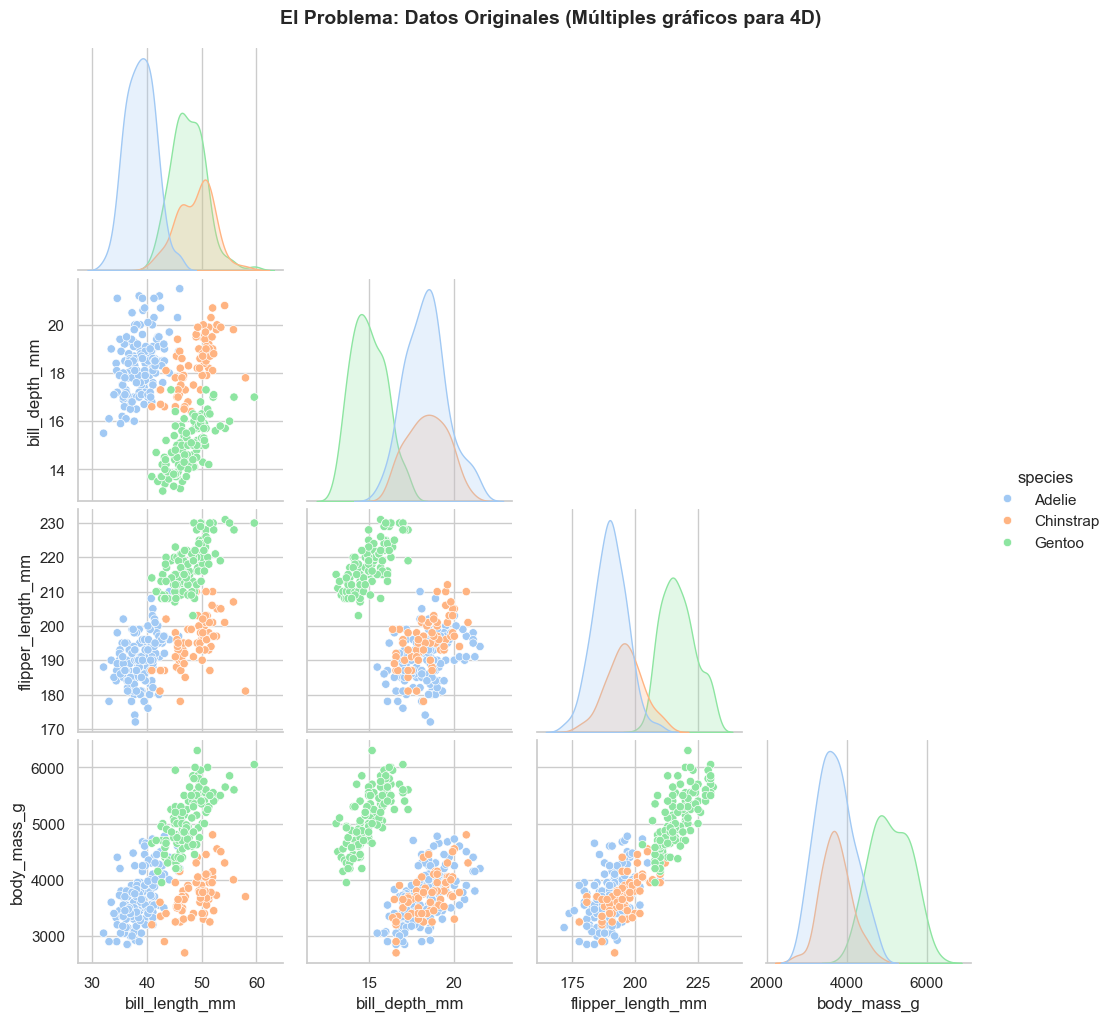

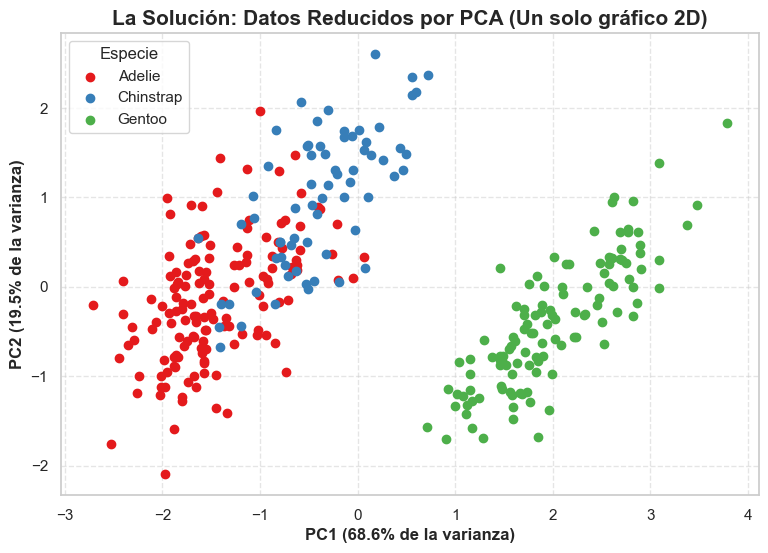

In [30]:
# Volvemos a trazar el Pairplot para mostrar lo engorroso que es ver 4 variables físicas a la vez
sns.pairplot(penguins_sexo[columnas_fisicas + ['species']], hue='species', corner=True)
plt.suptitle("El Problema: Datos Originales (Múltiples gráficos para 4D)", y=1.02, fontsize=14, fontweight='bold')
plt.show()
#la consigna pide la reduccion a n=2 componentes
pca_2d = PCA(n_components=2)
#reutilizamos Xz
X_pca_2d = pca_2d.fit_transform(Xz) 
varianza_2d = pca_2d.explained_variance_ratio_

plt.figure(figsize=(9, 6))
for especie in penguins_sexo["species"].unique():
    sel = (penguins_sexo["species"] == especie).to_numpy()
    plt.scatter(X_pca_2d[sel, 0], X_pca_2d[sel, 1], label=especie, color=colores[especie])
plt.xlabel(f"PC1 ({varianza_2d[0]:.1%} de la varianza)", fontweight='bold')
plt.ylabel(f"PC2 ({varianza_2d[1]:.1%} de la varianza)", fontweight='bold')
plt.title("La Solución: Datos Reducidos por PCA (Un solo gráfico 2D)", fontsize=15, fontweight='bold')
plt.legend(title="Especie")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Evaluación de la Pérdida de Información (Varianza Acumulada)
El gráfico del Criterio de Varianza Acumulada nos permite visualizar exactamente cuánta información ("varianza") retenemos y cuánta perdemos (el "ruido" que descartamos) por cada nivel de compresión dimensional que apliquemos:
1. **Reducción a 1 Dimensión (PC1):** 
   * **Retención:** 68.6%
   * **Pérdida:** 31.4%. 
   * *Análisis:* Reducir 4 variables a una sola línea recta implica perder casi un tercio de la información original. Es un nivel de compresión muy agresivo.
   
2. **Reducción a 2 Dimensiones (PC1 + PC2):** 
   * **Retención:** 88.1% (68.6% + 19.5%)
   * **Pérdida:** 11.9%. 
   * *Análisis:* Es el "punto dulce" (sweet spot) para la visualización humana. Descartamos apenas un 12% de los datos (la redundancia extrema) pero ganamos la capacidad de ver todo el ecosistema en un monitor plano (2D).
3. **Reducción a 3 Dimensiones (PC1 + PC2 + PC3):** 
   * **Retención:** 97.2%
   * **Pérdida:** 2.8%. 
   * *Análisis:* Aquí rompemos el umbral de confianza del 95% exigido. Perder menos de un 3% de información es estadísticamente despreciable, pero perdemos la capacidad de imprimir el gráfico fácilmente en papel.
4. **Sin Reducción (4 Dimensiones):** 
   * **Retención:** 100%
   * **Pérdida:** 0%. 
   * *Análisis:* Mantenemos el dataset original, pero sufrimos la Maldición de la Dimensionalidad (no podemos visualizar los datos sin usar decenas de sub-gráficos).

# Ejercicio 5: Diseño Visual y Narrativa de Datos 

## DASHBOARD

In [1]:
import sys
!{sys.executable} -m pip install plotly



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
!{sys.executable} -m pip install missingno



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import sys
!{sys.executable} -m streamlit run dashboard.py


: 